# E-Commerce Net Sales Prediction Model

**IBM SkillsBuild Data Analytics with AI — Academic Internship Program**
**Conducted by BharatCares, in association with AICTE**

**Project:** Predicting Order-Level Net Sales for an E-Commerce Platform using Machine Learning

**Author:** _Your Name_
**Dataset:** `ecommerce_sales_customer_analytics_150k-selected-columns.csv`

---

## 1. Problem Statement

E-commerce businesses generate huge volumes of order-level transactional data. Being able to
**predict the net sales value of an order** from its known attributes (channel, customer profile,
payment method, discounts, shipping costs, etc.) helps with:

- Revenue forecasting and financial planning
- Identifying which order/customer attributes drive higher-value sales
- Flagging orders whose expected value looks unusual (potential fraud/errors)
- Personalizing marketing spend around high-value customer segments

**Goal:** Build and compare regression models that predict `net_sales` for an order, using
features available at (or shortly after) order time — excluding any column that is mathematically
derived from `net_sales` itself (to avoid data leakage).


## Import Libraries


In [42]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.max_columns', 50)
print('Libraries loaded successfully')

Libraries loaded successfully


## Load the Dataset

In [43]:
df=pd.read_csv('ecommerce_sales_customer_analytics_150k-selected-columns (2).csv')
print('Shape:', df.shape)
df.head()

Shape: (66849, 25)


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,payment_method,payment_status,currency,return_status,return_reason,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Digital Wallet,Paid,USD,NaN,NaN,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Debit Card,Pending,EUR,NaN,NaN,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Cash on Delivery,Paid,USD,NaN,NaN,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,Debit Card,Paid,USD,NaN,NaN,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,Digital Wallet,Paid,INR,NaN,NaN,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66849 entries, 0 to 66848
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  66849 non-null  object 
 1   order_date                66849 non-null  object 
 2   order_time                66849 non-null  object 
 3   order_status              66849 non-null  object 
 4   sales_channel             66849 non-null  object 
 5   customer_id               66849 non-null  object 
 6   customer_name             66849 non-null  object 
 7   customer_age              66849 non-null  int64  
 8   gender                    66849 non-null  object 
 9   customer_segment          66849 non-null  object 
 10  payment_method            66849 non-null  object 
 11  payment_status            66849 non-null  object 
 12  currency                  66849 non-null  object 
 13  return_status             4551 non-null   object 
 14  return

In [45]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
customer_age,66849.0,45.824754,16.463178,18.00,32.00,46.00,60.00,74.00
discount_amount,66849.0,238.560433,379.954691,0.00,26.73,103.44,278.53,4833.87
tax_amount,66849.0,122.408106,141.631499,0.35,34.42,76.85,155.97,2091.52
shipping_cost,66849.0,22.321528,16.017406,0.00,9.84,19.26,30.77,149.52
net_sales,66849.0,1282.622021,1176.500785,5.80,448.40,945.09,1741.39,16218.00
product_cost,66849.0,709.201240,735.093607,1.97,207.19,476.22,952.32,9963.41
profit,66849.0,551.099253,517.845818,-1281.59,189.61,406.26,753.03,7083.68
profit_margin_percentage,66849.0,45.077737,13.164029,-56.93,38.90,47.02,53.80,77.59
customer_lifetime_value,66849.0,8974.009871,4426.247458,44.50,5719.31,8384.93,11665.92,30268.44
customer_order_count,66849.0,6.992670,2.440534,1.00,5.00,7.00,9.00,20.00


## Exploratory Data Analysis(EDA)

 Missing Values

In [46]:
missing =df.isnull().sum()
missing = missing[missing>0]
print(missing)
print('\nNote: return_status / return_reason are NaN for orders that were never returned. '
      'This is expected — not an error.')

return_status    62298
return_reason    62298
dtype: int64

Note: return_status / return_reason are NaN for orders that were never returned. This is expected — not an error.


Target Variable- net_sales Distribution

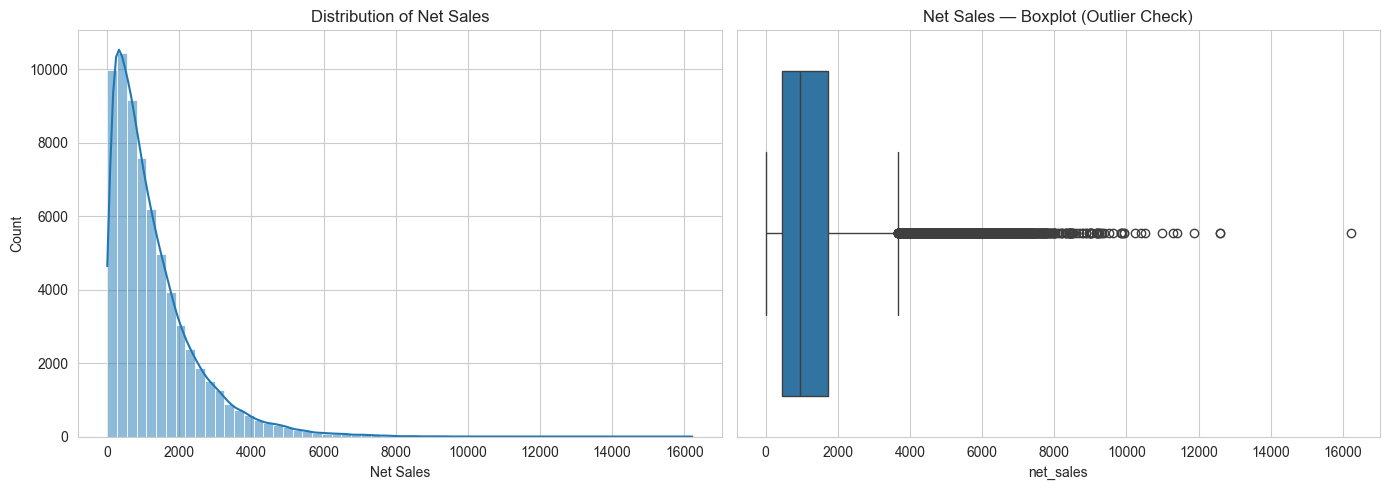

count    66849.000000
mean      1282.622021
std       1176.500785
min          5.800000
25%        448.400000
50%        945.090000
75%       1741.390000
max      16218.000000
Name: net_sales, dtype: float64


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['net_sales'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Net Sales')
axes[0].set_xlabel('Net Sales')

sns.boxplot(x=df['net_sales'], ax=axes[1])
axes[1].set_title('Net Sales — Boxplot (Outlier Check)')
plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=120)
plt.show()

print(df['net_sales'].describe())

Categorical Feature Breakdown

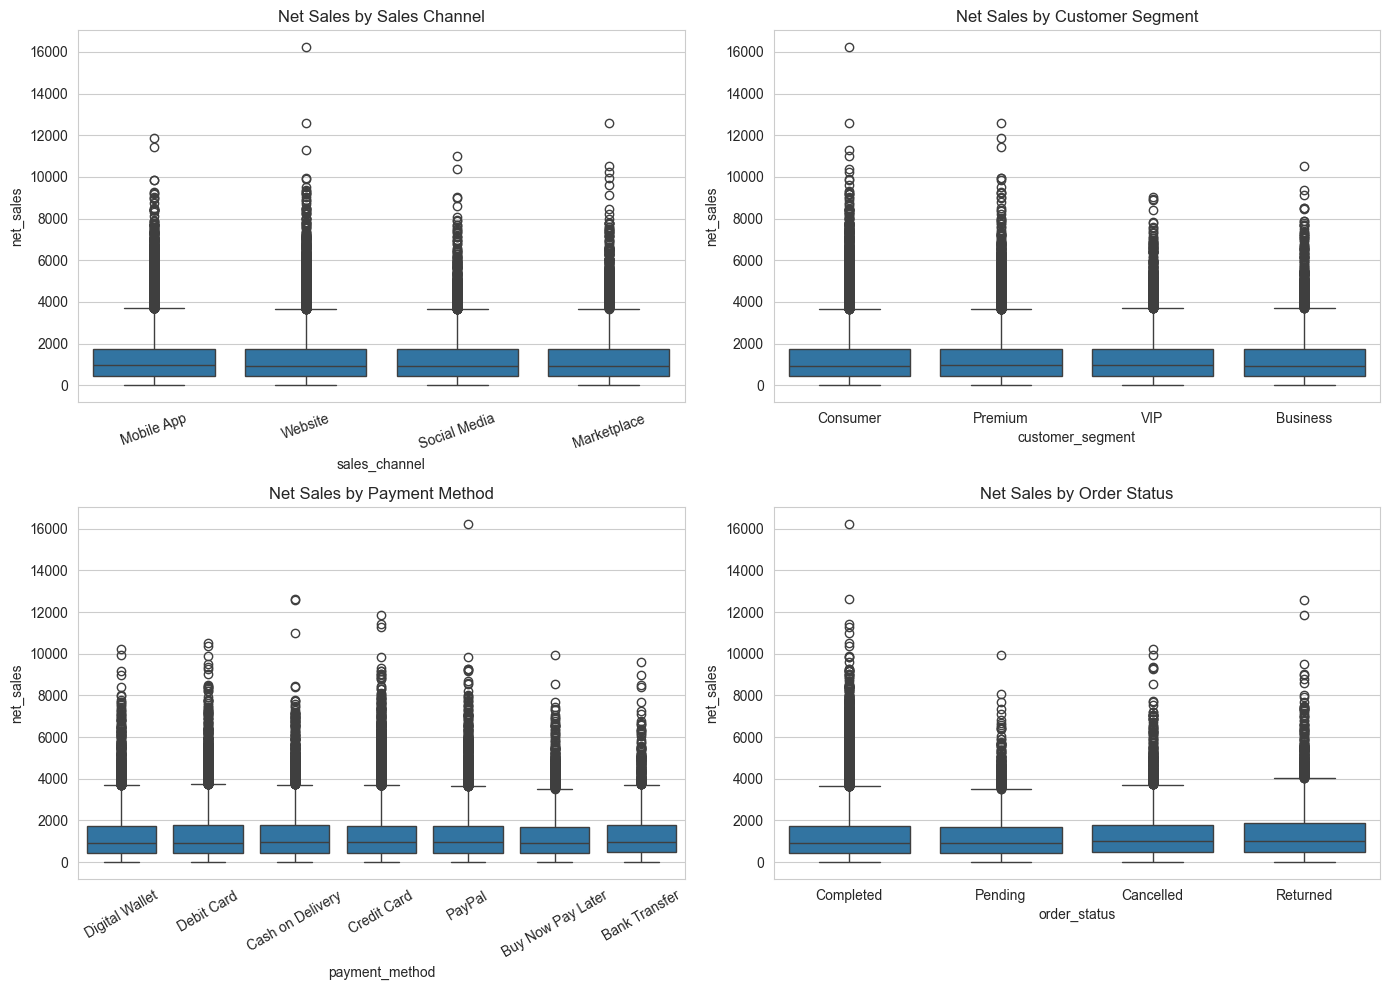

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='sales_channel', y='net_sales', ax=axes[0,0])
axes[0,0].set_title('Net Sales by Sales Channel')
axes[0,0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='customer_segment', y='net_sales', ax=axes[0,1])
axes[0,1].set_title('Net Sales by Customer Segment')

sns.boxplot(data=df, x='payment_method', y='net_sales', ax=axes[1,0])
axes[1,0].set_title('Net Sales by Payment Method')
axes[1,0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='order_status', y='net_sales', ax=axes[1,1])
axes[1,1].set_title('Net Sales by Order Status')

plt.tight_layout()
plt.savefig('fig_categorical_breakdown.png', dpi=120)
plt.show()


Sales Trend Over Time

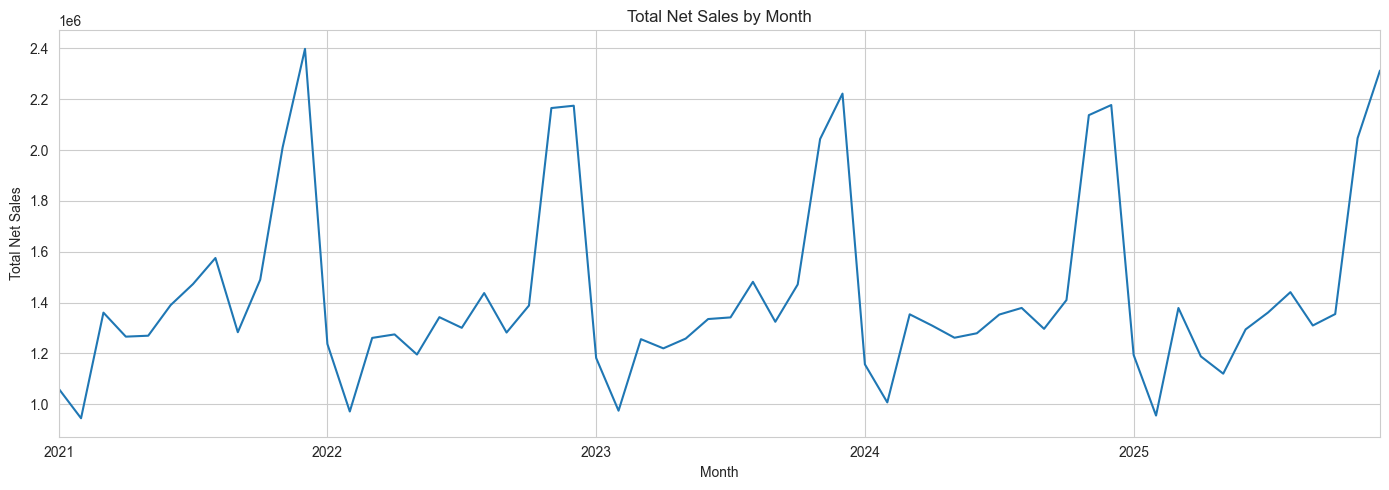

In [49]:
df['order_date']= pd.to_datetime(df['order_date'])
monthly_sales = df.set_index('order_date').resample('ME')['net_sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot()
plt.title('Total Net Sales by Month')
plt.ylabel('Total Net Sales')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('fig_sales_trend.png', dpi=120)
plt.show()

Correlation Heatmap(Numeric Features)

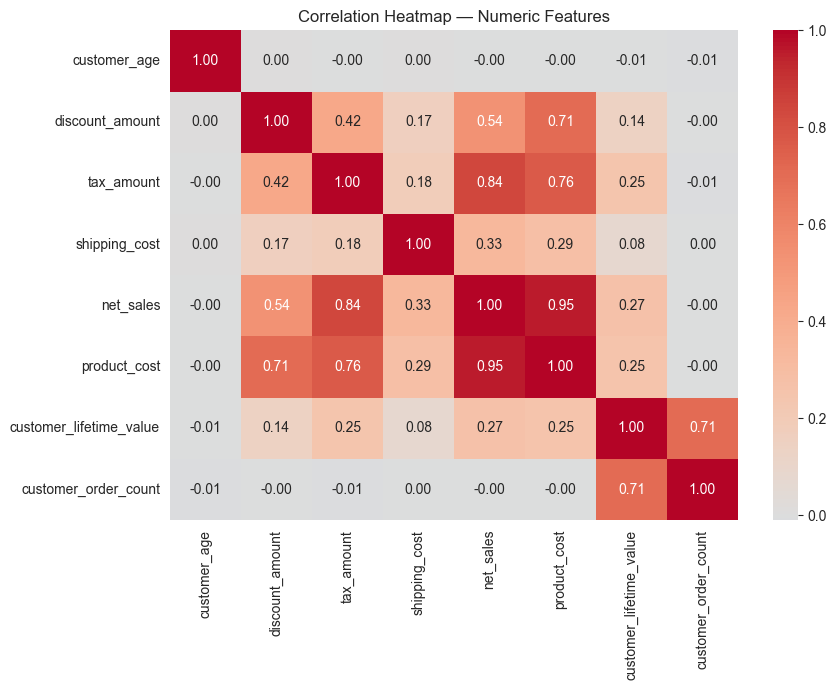

In [50]:
numeric_cols = ['customer_age', 'discount_amount', 'tax_amount', 'shipping_cost',
                 'net_sales', 'product_cost', 'customer_lifetime_value', 'customer_order_count']

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=120)
plt.show()


## Date Cleaning

Steps performed:
1. Check and remove exact duplicate rows.
2. Fill `return_status` / `return_reason` missing values with `'Not Returned'` — these are
   structurally missing (order was never returned), not bad data.
3. Confirm no missing values remain in the columns we will actually use.
4. Confirm data types are sensible (dates parsed, numeric columns numeric).

In [51]:
print('Duplicate Rows:', df.duplicated().sum())
df=df.drop_duplicates()

df['return_status']=df['return_status'].fillna('Not Returned')
df['return_status']=df['return_status'].fillna('Not Returned')

print('Remaining missing values:')
print(df.isnull().sum().sum())

Duplicate Rows: 0
Remaining missing values:
62298


## Feature Engineering

###  Avoiding Data Leakage

`profit` and `profit_margin_percentage` are **mathematically derived from `net_sales`**
(`profit ≈ net_sales - product_cost`). If we included them as predictors, the model would
effectively "cheat" by reverse-engineering the target instead of learning genuine patterns.
We drop both.

We also drop pure identifiers that carry no generalizable signal (`order_id`, `customer_id`,
`customer_name`) and `currency` handling is kept as a categorical feature since amounts are
stored in their local currency value.

### Date/Time Features

We extract `order_month`, `order_weekday`, and `order_hour` from the date/time columns, which
can capture seasonality and time-of-day purchasing patterns.

In [52]:
df['order_month'] = df['order_date'].dt.month
df['order_weekday'] = df['order_date'].dt.day_name()
df['order_hour'] = pd.to_datetime(df['order_time'], format='%H:%M:%S').dt.hour

leakage_cols = ['profit', 'profit_margin_percentage']
id_cols = ['order_id', 'customer_id', 'customer_name', 'order_date', 'order_time']

model_df = df.drop(columns=leakage_cols + id_cols)
model_df.head()

,order_status,sales_channel,customer_age,gender,customer_segment,payment_method,payment_status,currency,return_status,return_reason,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,customer_lifetime_value,is_repeat_customer,customer_order_count,order_month,order_weekday,order_hour
0,Completed,Mobile App,55,Male,Consumer,Digital Wallet,Paid,USD,Not Returned,NaN,477.89,61.07,12.03,945.40,588.33,12459.68,True,11,11,Monday,16
1,Completed,Website,26,Male,Premium,Debit Card,Pending,EUR,Not Returned,NaN,1456.06,320.83,9.00,2018.41,2031.88,13032.48,True,11,12,Wednesday,1
2,Completed,Mobile App,69,Female,Premium,Cash on Delivery,Paid,USD,Not Returned,NaN,97.30,29.79,13.05,468.35,257.73,6159.44,True,6,7,Monday,14
3,Completed,Social Media,65,Male,Consumer,Debit Card,Paid,USD,Not Returned,NaN,53.34,34.39,20.85,546.52,277.84,5638.30,True,7,1,Saturday,7
4,Completed,Social Media,34,Female,Consumer,Digital Wallet,Paid,INR,Not Returned,NaN,133.63,421.35,23.03,2785.27,1231.88,13240.10,True,8,5,Friday,9


In [53]:
target = 'net_sales'
y = model_df[target]
X = model_df.drop(columns=[target])

categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical features:', categorical_features)
print('Numeric features:', numeric_features)

Categorical features: ['order_status', 'sales_channel', 'gender', 'customer_segment', 'payment_method', 'payment_status', 'currency', 'return_status', 'return_reason', 'is_repeat_customer', 'order_weekday']
Numeric features: ['customer_age', 'discount_amount', 'tax_amount', 'shipping_cost', 'product_cost', 'customer_lifetime_value', 'customer_order_count']


## Train/Test Split

We use an 80/20 split. Preprocessing (one-hot encoding for categoricals, scaling for numerics)
is wrapped in a `ColumnTransformer` inside a `Pipeline`, fitted **only on the training set**, to
avoid any leakage from the test set.


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

Train shape: (53479, 20)
Test shape : (13370, 20)


## Model Building

We train and compare four regression models:

1. **Linear Regression** — simple baseline
2. **Ridge Regression** — regularized linear baseline
3. **Random Forest Regressor** — non-linear, handles interactions
4. **XGBoost Regressor** — gradient-boosted trees, typically strongest performer on tabular data

In [55]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08,
                             random_state=42, n_jobs=-1)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2})
    fitted_pipelines[name] = pipe
    print(f'{name:20s} | MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | R2: {r2:.4f}')


Linear Regression    | MAE:   133.97 | RMSE:   194.88 | R2: 0.9726
Ridge Regression     | MAE:   133.98 | RMSE:   194.88 | R2: 0.9726
Random Forest        | MAE:    27.60 | RMSE:    82.27 | R2: 0.9951
XGBoost              | MAE:    25.34 | RMSE:    70.04 | R2: 0.9965


## Model Comparison

In [56]:
results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2 Score
0,XGBoost,25.341126,70.036260,0.996466
1,Random Forest,27.600059,82.265281,0.995124
2,Linear Regression,133.974455,194.877343,0.972639
3,Ridge Regression,133.975255,194.877458,0.972639


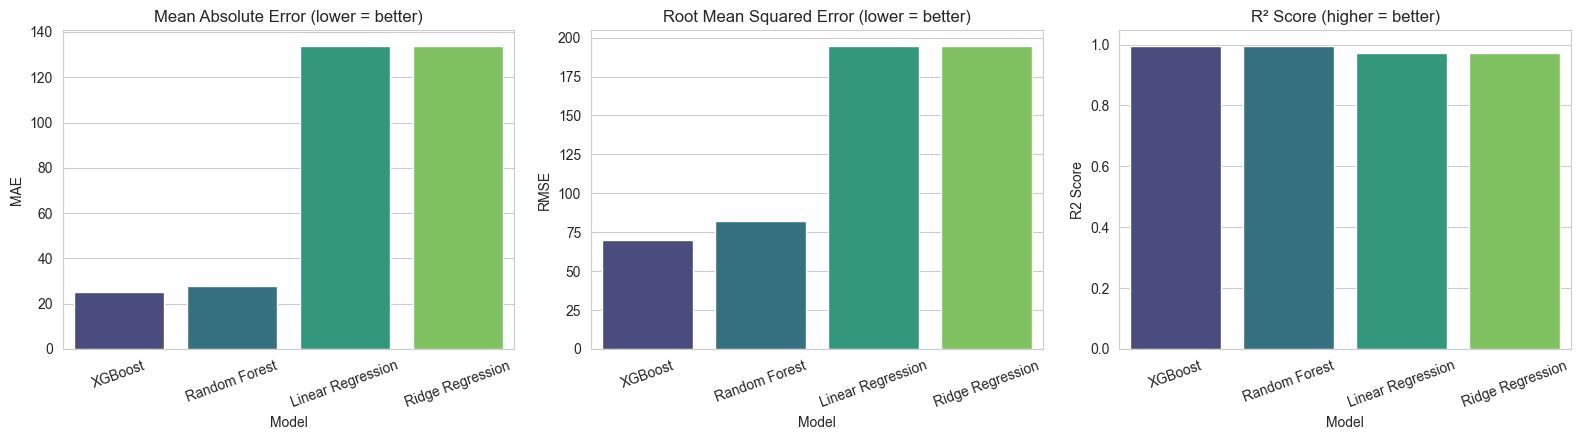

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=results_df, x='Model', y='MAE', ax=axes[0], palette='viridis')
axes[0].set_title('Mean Absolute Error (lower = better)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1], palette='viridis')
axes[1].set_title('Root Mean Squared Error (lower = better)')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='R2 Score', ax=axes[2], palette='viridis')
axes[2].set_title('R² Score (higher = better)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=120)
plt.show()

## Best Model - Detailed Evaluation

We select the model with the highest R² / lowest error and inspect it further:
predicted-vs-actual values and feature importance.

In [58]:
best_model_name = results_df.iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]
best_preds = best_pipeline.predict(X_test)

print('Best performing model:', best_model_name)
print(results_df.iloc[0])

Best performing model: XGBoost
Model         XGBoost
MAE         25.341126
RMSE         70.03626
R2 Score     0.996466
Name: 0, dtype: object


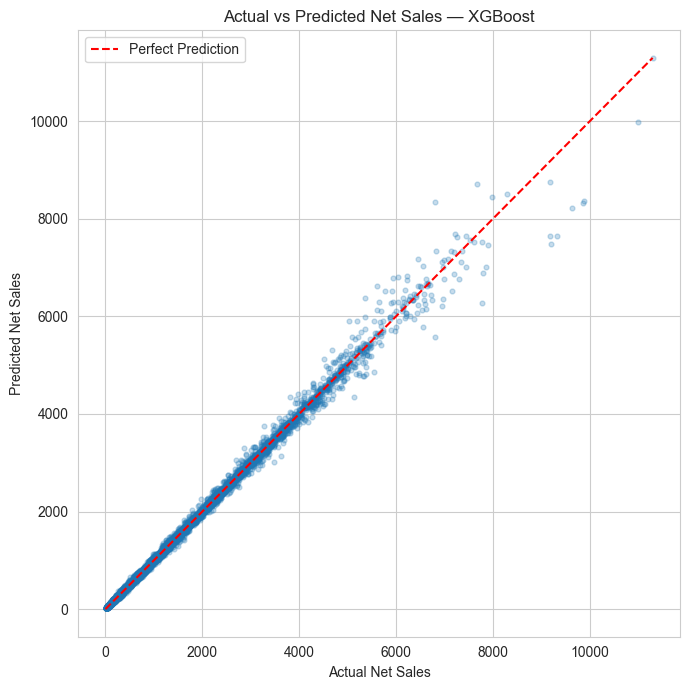

In [59]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.25, s=12)
lims = [0, max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual Net Sales')
plt.ylabel('Predicted Net Sales')
plt.title(f'Actual vs Predicted Net Sales — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('fig_actual_vs_predicted.png', dpi=120)
plt.show()

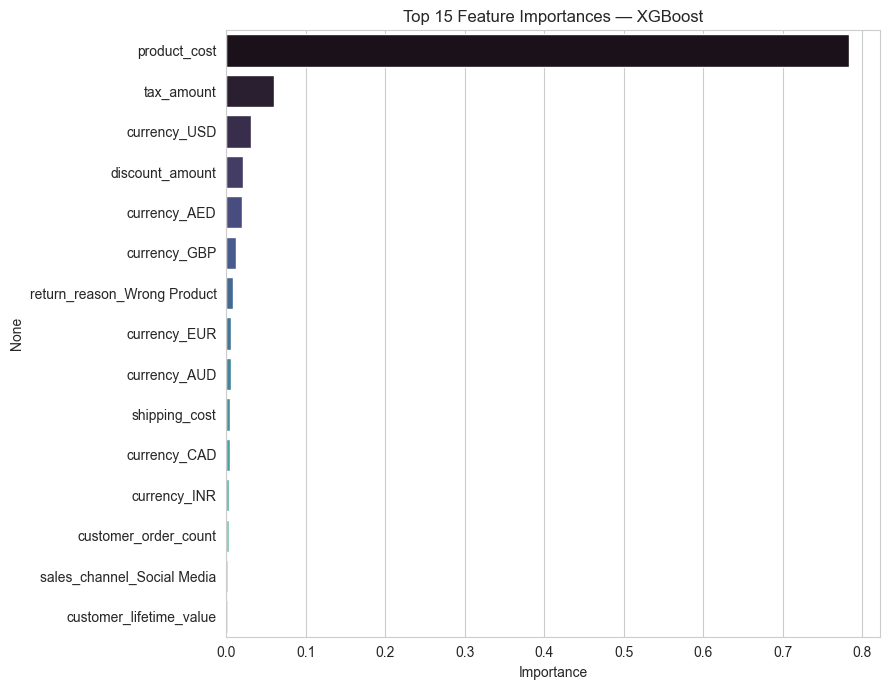

In [60]:
# Feature importance (works for tree-based models)
if best_model_name in ('Random Forest', 'XGBoost'):
    ohe = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    all_feature_names = np.concatenate([numeric_features, cat_feature_names])

    importances = best_pipeline.named_steps['model'].feature_importances_
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='mako')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('fig_feature_importance.png', dpi=120)
    plt.show()
else:
    print('Selected model is linear — see coefficients instead of tree feature_importances_.')



##  Save the Trained Model

We persist the best pipeline (preprocessing + model bundled together) with `joblib`, so it can
be reloaded later and used directly on new raw order data without repeating any preprocessing
code.

In [61]:
joblib.dump(best_pipeline, 'best_net_sales_model.pkl')
print(f'Saved best model ({best_model_name}) to best_net_sales_model.pkl')


Saved best model (XGBoost) to best_net_sales_model.pkl


##  Conclusion

- We built and compared four regression models to predict order-level **net sales** for an
  e-commerce platform: Linear Regression, Ridge Regression, Random Forest, and XGBoost.
- Columns that were mathematically derived from the target (`profit`, `profit_margin_percentage`)
  were deliberately excluded to prevent data leakage and keep the model honest.
- Tree-based ensemble models (Random Forest / XGBoost) outperformed the linear baselines,
  indicating non-linear relationships and feature interactions in the data.
- Feature importance analysis highlights which order/customer attributes most influence
  predicted sales value — useful for business stakeholders beyond just the prediction itself.

### Limitations
- The model is trained on historical data and may not adapt automatically to new trends (concept drift).
- Categorical encoding via one-hot means the model cannot generalize to categories unseen during training.
- No hyperparameter tuning (e.g. GridSearchCV) was performed here for scope reasons — this is a
  natural next step to further improve performance.

### Future Work
- Hyperparameter tuning (GridSearchCV / Optuna) on the best model.
- Try additional models (LightGBM, CatBoost, neural networks).
- Deploy the saved pipeline behind a simple API/web app for real-time predictions.

In [62]:
import joblib
import pandas as pd

# 1. Load the model
model = joblib.load("best_net_sales_model.pkl")

# 2. Prepare a sample of new orders (must have the same raw columns as training)
new_orders = pd.DataFrame([{
    "order_status": "Completed",
    "sales_channel": "Website",
    "customer_age": 34,
    "gender": "Female",
    "customer_segment": "Premium",
    "payment_method": "Credit Card",
    "payment_status": "Paid",
    "currency": "USD",
    "discount_amount": 15.0,
    "tax_amount": 22.5,
    "shipping_cost": 8.0,
    "product_cost": 250.0,
    "customer_lifetime_value": 3200.0,
    "is_repeat_customer": True,
    "customer_order_count": 5,
    "return_status": "Not Returned",
    "return_reason": "Not Returned",
    "order_month": 9,
    "order_weekday": "Tuesday",
    "order_hour": 14,
}])

# 3. Predict
predictions = model.predict(new_orders)
print("Predicted net sales:", predictions[0])

Predicted net sales: 370.8553
